In [3]:
!unzip -q archive.zip -d data

Model şu cihazda çalışacak: cuda
Sınıflar: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Eğitim başlıyor...
Epoch 1/20 -> Train Acc: %28.83 | Val Acc: %39.05
Epoch 2/20 -> Train Acc: %38.76 | Val Acc: %44.85
Epoch 3/20 -> Train Acc: %41.95 | Val Acc: %46.94
Epoch 4/20 -> Train Acc: %44.36 | Val Acc: %50.10
Epoch 5/20 -> Train Acc: %46.39 | Val Acc: %52.86
Epoch 6/20 -> Train Acc: %47.12 | Val Acc: %52.40
Epoch 7/20 -> Train Acc: %48.19 | Val Acc: %51.78
Epoch 8/20 -> Train Acc: %49.07 | Val Acc: %53.51
Epoch 9/20 -> Train Acc: %50.03 | Val Acc: %54.83
Epoch 10/20 -> Train Acc: %50.70 | Val Acc: %55.70
Epoch 11/20 -> Train Acc: %51.73 | Val Acc: %55.89
Epoch 12/20 -> Train Acc: %52.34 | Val Acc: %56.51
Epoch 13/20 -> Train Acc: %52.74 | Val Acc: %56.91
Epoch 14/20 -> Train Acc: %53.05 | Val Acc: %57.11
Epoch 15/20 -> Train Acc: %53.74 | Val Acc: %57.38
Epoch 16/20 -> Train Acc: %54.01 | Val Acc: %58.09
Epoch 17/20 -> Train Acc: %54.37 | Val Acc: %58.02
Epoch 18/20 

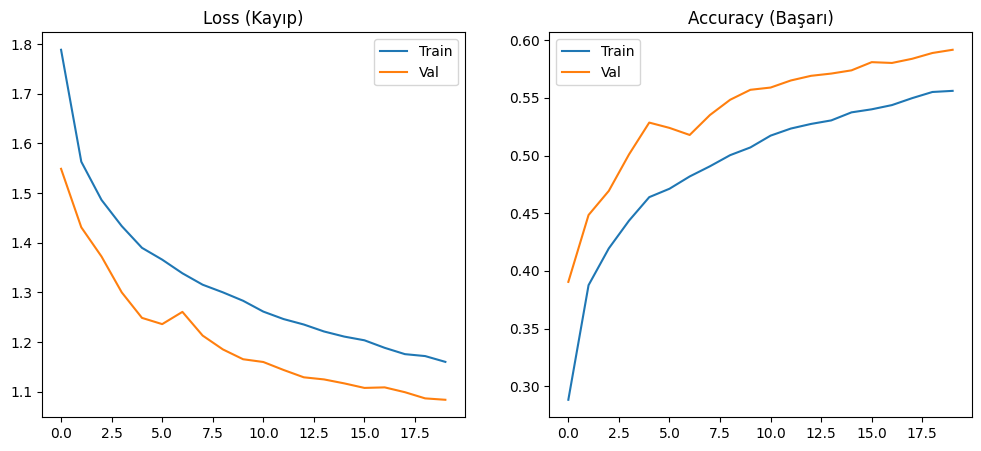

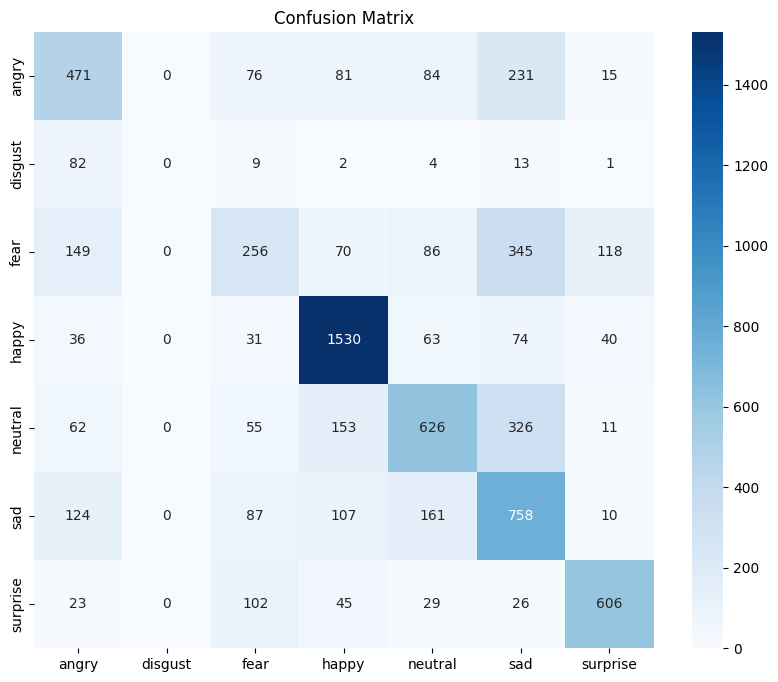

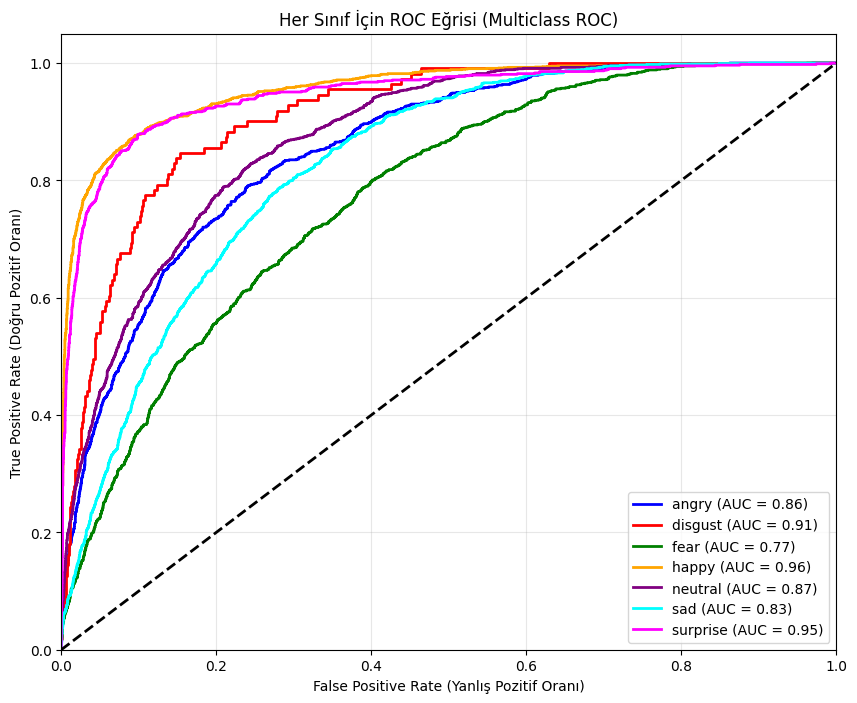


Sınıflandırma Raporu:
              precision    recall  f1-score   support

       angry       0.50      0.49      0.49       958
     disgust       0.00      0.00      0.00       111
        fear       0.42      0.25      0.31      1024
       happy       0.77      0.86      0.81      1774
     neutral       0.59      0.51      0.55      1233
         sad       0.43      0.61      0.50      1247
    surprise       0.76      0.73      0.74       831

    accuracy                           0.59      7178
   macro avg       0.49      0.49      0.49      7178
weighted avg       0.58      0.59      0.58      7178



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
import seaborn as sns
import os
from itertools import cycle


BATCH_SIZE = 64
LEARNING_RATE = 0.001
EPOCHS = 20
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Model şu cihazda çalışacak: {DEVICE}")


if os.path.exists('./data/train'):
    train_dir = './data/train'
    test_dir = './data/test'
elif os.path.exists('./data/fer2013/train'):
    train_dir = './data/fer2013/train'
    test_dir = './data/fer2013/test'
else:
    print("HATA: Veri klasörü bulunamadı! Lütfen zip dosyasını çıkardığından emin ol.")
    train_dir = ''

if train_dir:

    data_transforms = {
        'train': transforms.Compose([
            transforms.Grayscale(num_output_channels=1),
            transforms.RandomHorizontalFlip(),
            transforms.RandomRotation(10),
            transforms.ToTensor(),
            transforms.Normalize((0.5,), (0.5,))
        ]),
        'val': transforms.Compose([
            transforms.Grayscale(num_output_channels=1),
            transforms.ToTensor(),
            transforms.Normalize((0.5,), (0.5,))
        ]),
    }

    train_dataset = datasets.ImageFolder(train_dir, transform=data_transforms['train'])
    val_dataset = datasets.ImageFolder(test_dir, transform=data_transforms['val'])

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

    class_names = train_dataset.classes
    n_classes = len(class_names)
    print(f"Sınıflar: {class_names}")


    class CustomFaceCNN(nn.Module):
        def __init__(self, num_classes=7):
            super(CustomFaceCNN, self).__init__()
            # Blok 1
            self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
            self.bn1 = nn.BatchNorm2d(32)
            self.pool1 = nn.MaxPool2d(2, 2)
            # Blok 2
            self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
            self.bn2 = nn.BatchNorm2d(64)
            self.pool2 = nn.MaxPool2d(2, 2)
            # Blok 3
            self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
            self.bn3 = nn.BatchNorm2d(128)
            self.pool3 = nn.MaxPool2d(2, 2)

            # Flatten
            self.fc1 = nn.Linear(128 * 6 * 6, 512)
            self.dropout = nn.Dropout(0.5)
            self.fc2 = nn.Linear(512, num_classes)

        def forward(self, x):
            x = self.pool1(F.relu(self.bn1(self.conv1(x))))
            x = self.pool2(F.relu(self.bn2(self.conv2(x))))
            x = self.pool3(F.relu(self.bn3(self.conv3(x))))
            x = x.view(x.size(0), -1)
            x = F.relu(self.fc1(x))
            x = self.dropout(x)
            x = self.fc2(x)
            return x

    model = CustomFaceCNN(num_classes=n_classes).to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)


    def train_model(num_epochs=20):
        history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
        best_acc = 0.0

        print("Eğitim başlıyor...")

        for epoch in range(num_epochs):
            model.train()
            running_loss, correct, total = 0.0, 0, 0

            for inputs, labels in train_loader:
                inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
                optimizer.zero_grad()
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

            epoch_loss = running_loss / len(train_dataset)
            epoch_acc = correct / total


            model.eval()
            val_loss, correct, total = 0.0, 0, 0
            with torch.no_grad():
                for inputs, labels in val_loader:
                    inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                    val_loss += loss.item() * inputs.size(0)
                    _, predicted = torch.max(outputs, 1)
                    total += labels.size(0)
                    correct += (predicted == labels).sum().item()

            val_loss = val_loss / len(val_dataset)
            val_acc = correct / total

            history['train_loss'].append(epoch_loss)
            history['train_acc'].append(epoch_acc)
            history['val_loss'].append(val_loss)
            history['val_acc'].append(val_acc)

            print(f"Epoch {epoch+1}/{num_epochs} -> Train Acc: %{epoch_acc*100:.2f} | Val Acc: %{val_acc*100:.2f}")

            if val_acc > best_acc:
                best_acc = val_acc
                torch.save(model.state_dict(), 'best_custom_cnn.pth')

        print(f"Eğitim bitti. En iyi skor: %{best_acc*100:.2f}")
        return history


    history = train_model(EPOCHS)




    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='Train')
    plt.plot(history['val_loss'], label='Val')
    plt.title('Loss (Kayıp)')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history['train_acc'], label='Train')
    plt.plot(history['val_acc'], label='Val')
    plt.title('Accuracy (Başarı)')
    plt.legend()
    plt.savefig('performance_graphs.png')
    plt.show()


    model.load_state_dict(torch.load('best_custom_cnn.pth'))
    model.eval()

    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs = inputs.to(DEVICE)
            outputs = model(inputs)


            probs = F.softmax(outputs, dim=1)
            all_probs.extend(probs.cpu().numpy())

            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())


    plt.figure(figsize=(10,8))
    cm = confusion_matrix(all_labels, all_preds)
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
    plt.title('Confusion Matrix')
    plt.savefig('confusion_matrix.png')
    plt.show()


    y_test_bin = label_binarize(all_labels, classes=list(range(n_classes)))
    y_score = np.array(all_probs)

    plt.figure(figsize=(10, 8))
    colors = cycle(['blue', 'red', 'green', 'orange', 'purple', 'cyan', 'magenta'])

    for i, color in zip(range(n_classes), colors):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, color=color, lw=2,
                 label=f'{class_names[i]} (AUC = {roc_auc:.2f})')

    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (Yanlış Pozitif Oranı)')
    plt.ylabel('True Positive Rate (Doğru Pozitif Oranı)')
    plt.title('Her Sınıf İçin ROC Eğrisi (Multiclass ROC)')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.savefig('roc_curve.png')
    plt.show()

    print("\nSınıflandırma Raporu:")
    print(classification_report(all_labels, all_preds, target_names=class_names))

else:
    print("Kod çalıştırılamadı çünkü veri klasörü yok.")